# DAM304 Practical 4: Construct a Small-Scale Language Model

**Unit IV: LLM Architectures and Implementation**

In this practical, you will assemble all components of a complete language model:
- Token embeddings and positional encoding
- Stacked transformer blocks
- Language model head
- Complete training loop with causal language modeling
- Autoregressive text generation

By the end, you will have trained a mini-LM and generated text from it.

## Section 1: Environment Setup

In [1]:
# Install required libraries
import subprocess
import sys

try:
    import torch
    import numpy as np
    import matplotlib.pyplot as plt
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "numpy", "matplotlib"])
    import torch
    import numpy as np
    import matplotlib.pyplot as plt

print("Libraries installed successfully!")

Libraries installed successfully!


In [2]:
# Import all required libraries
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

PyTorch version: 2.11.0
Device: cpu


## Section 2: Copy Components from Practical 3

Import the MultiHeadAttention and TransformerBlock from Practical 3.

In [3]:
class FeedForward(nn.Module):
    """Position-wise feed-forward network: FFN(x) = GELU(xW1 + b1)W2 + b2"""
    
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.act = nn.GELU()
    
    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

In [4]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention from Practical 3."""
    
    def __init__(self, d_model, num_heads, dropout=0.0):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)
        
        self.dropout = nn.Dropout(dropout)
    
    def split_heads(self, x, B, n):
        """Reshape (B, n, d_model) -> (B, num_heads, n, d_k)"""
        x = x.view(B, n, self.num_heads, self.d_k)
        return x.transpose(1, 2)
    
    def forward(self, x, causal=False):
        B, n, d_model = x.shape
        
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)
        
        Q = self.split_heads(Q, B, n)
        K = self.split_heads(K, B, n)
        V = self.split_heads(V, B, n)
        
        scores = torch.matmul(Q, K.transpose(-2, -1))
        scores = scores / math.sqrt(self.d_k)
        
        if causal:
            mask = torch.tril(torch.ones(n, n, device=x.device)).bool()
            mask = mask.unsqueeze(0).unsqueeze(0)
            scores = scores.masked_fill(~mask, float('-inf'))
        
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)
        
        context = torch.matmul(weights, V)
        context = context.transpose(1, 2)
        context = context.contiguous().view(B, n, d_model)
        
        output = self.W_O(context)
        
        return output, weights

print("MultiHeadAttention imported successfully!")

MultiHeadAttention imported successfully!


In [5]:
class TransformerBlock(nn.Module):
    """One transformer layer (Pre-LN variant) from Practical 3."""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff = FeedForward(d_model, d_ff)
        self.drop = nn.Dropout(dropout)
    
    def forward(self, x, causal=False):
        """Forward pass with residual connections."""
        # Attention block with residual
        attn_out, weights = self.attn(self.norm1(x), causal=causal)
        x = x + self.drop(attn_out)
        
        # Feed-forward block with residual
        ff_out = self.ff(self.norm2(x))
        x = x + self.drop(ff_out)
        
        return x, weights

print("TransformerBlock imported successfully!")

TransformerBlock imported successfully!


## Task 1: Mini Language Model Architecture

In [6]:
class MiniLM(nn.Module):
    """A small autoregressive language model.
    
    Args:
        vocab_size : int — number of unique tokens
        d_model : int — embedding dimension
        num_heads : int — attention heads per block
        num_layers : int — number of transformer blocks
        d_ff : int — FFN inner dimension
        max_seq_len : int — maximum sequence length for PE
        dropout : float
    """
    
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        
        # [TASK 1.1] Token embedding layer
        self.token_emb = nn.Embedding(vocab_size, d_model)
        
        # [TASK 1.1] Sinusoidal positional encoding
        # Build PE matrix: shape (1, max_seq_len, d_model)
        PE = torch.zeros(1, max_seq_len, d_model)
        pos = torch.arange(max_seq_len).unsqueeze(1)  # (max_seq_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        
        PE[:, :, 0::2] = torch.sin(pos * div_term)  # Even indices
        if d_model % 2 == 1:
            PE[:, :, 1::2] = torch.cos(pos * div_term[:-1])  # Odd indices (handle odd d_model)
        else:
            PE[:, :, 1::2] = torch.cos(pos * div_term)  # Odd indices
        
        # Register as non-trainable buffer
        self.register_buffer('pos_enc', PE)
        
        # [PROVIDED] Stack of transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # [PROVIDED] Layer normalization and language model head
        self.norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        
        self.max_seq_len = max_seq_len
    
    def forward(self, x):  # x: (B, T) token IDs
        """Forward pass through the language model.
        
        Args:
            x : Tensor of shape (B, T) containing token IDs
            
        Returns:
            logits : Tensor of shape (B, T, vocab_size)
        """
        B, T = x.shape
        
        # [TASK 1.2a] Embed tokens
        emb = self.token_emb(x)  # (B, T, d_model)
        
        # [TASK 1.2b] Add positional encoding
        emb = emb + self.pos_enc[:, :T, :]  # (B, T, d_model)
        
        # [TASK 1.2c] Apply dropout
        x = self.dropout(emb)
        
        # [TASK 1.2d] Pass through each transformer block with causal masking
        for block in self.blocks:
            x, _ = block(x, causal=True)
        
        # [TASK 1.2e] Apply final layer norm
        x = self.norm(x)
        
        # [TASK 1.2f] Apply language model head to get logits
        logits = self.lm_head(x)  # (B, T, vocab_size)
        
        return logits
    
    @torch.no_grad()
    def generate(self, prompt_ids, max_new_tokens=50, temperature=1.0):
        """Autoregressive text generation.
        
        Args:
            prompt_ids : list of token IDs to start with
            max_new_tokens : int, number of tokens to generate
            temperature : float, controls randomness (1.0 = unchanged)
            
        Returns:
            generated_ids : list of token IDs
        """
        # [TASK 1.3a] Convert prompt to tensor
        ids = torch.tensor([prompt_ids], dtype=torch.long)  # (1, T)
        
        # [TASK 1.3b] Generate tokens one at a time
        for _ in range(max_new_tokens):
            # Crop to max_seq_len to avoid exceeding context window
            ids_cropped = ids[:, -self.max_seq_len:]
            
            # Forward pass
            logits = self(ids_cropped)  # (1, T, vocab_size)
            
            # [TASK 1.3b] Get logits at last position and scale by temperature
            logits_next = logits[:, -1, :] / temperature  # (1, vocab_size)
            
            # [TASK 1.3b] Apply softmax to get probabilities
            probs = F.softmax(logits_next, dim=-1)  # (1, vocab_size)
            
            # [TASK 1.3b] Sample next token
            next_token = torch.multinomial(probs, 1)  # (1, 1)
            
            # [TASK 1.3b] Append to sequence
            ids = torch.cat([ids, next_token], dim=-1)
        
        # [TASK 1.3c] Return as list
        return ids.squeeze(0).tolist()

print("MiniLM class defined successfully!")

MiniLM class defined successfully!


In [7]:
# [TASK 1.4] Test the MiniLM architecture
torch.manual_seed(42)

# Create model instance
vocab_size = 100
d_model = 128
num_heads = 4
num_layers = 2
d_ff = 256
max_seq_len = 64

model = MiniLM(vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_len)
print(f"Model created with {sum(p.numel() for p in model.parameters()):,} parameters")

# Test forward pass
x_test = torch.randint(0, vocab_size, (2, 32))  # (batch=2, seq_len=32)
logits = model(x_test)

print(f"\n[TEST] Input shape: {x_test.shape}")
print(f"[TEST] Output logits shape: {logits.shape}")
print(f"[TEST] Expected shape: (2, 32, 100)")
print(f"[TEST] ✓ Shape correct: {logits.shape == (2, 32, vocab_size)}")

Model created with 289,792 parameters

[TEST] Input shape: torch.Size([2, 32])
[TEST] Output logits shape: torch.Size([2, 32, 100])
[TEST] Expected shape: (2, 32, 100)
[TEST] ✓ Shape correct: True


## Task 2: Character-Level Dataset

In [8]:
# Tiny training corpus
TEXT = """To be or not to be that is the question.
Whether tis nobler in the mind to suffer.
The slings and arrows of outrageous fortune.
Or to take arms against a sea of troubles."""

class CharDataset(Dataset):
    """Character-level dataset for language modeling."""
    
    def __init__(self, text, seq_len):
        self.seq_len = seq_len
        
        # Build vocabulary
        chars = sorted(set(text))
        self.vocab = {c: i for i, c in enumerate(chars)}
        self.inv_vocab = {i: c for c, i in self.vocab.items()}
        
        # Tokenize text
        self.data = torch.tensor([self.vocab[c] for c in text], dtype=torch.long)
    
    def __len__(self):
        return len(self.data) - self.seq_len
    
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

print("CharDataset class defined successfully!")

CharDataset class defined successfully!


In [9]:
# [TASK 2.1] Create dataset with seq_len=32
seq_len = 32
dataset = CharDataset(TEXT, seq_len)

print(f"\n[TASK 2] Character-Level Dataset")
print(f"Dataset length: {len(dataset)}")
print(f"Vocabulary size: {len(dataset.vocab)}")
print(f"Sequence length: {seq_len}")

# [TASK 2.4] Print vocabulary
print(f"\nVocabulary (all unique characters):")
for char, idx in sorted(dataset.vocab.items(), key=lambda x: x[1]):
    print(f"  {repr(char):5s} -> {idx:3d}")


[TASK 2] Character-Level Dataset
Dataset length: 138
Vocabulary size: 25
Sequence length: 32

Vocabulary (all unique characters):
  '\n'  ->   0
  ' '   ->   1
  '.'   ->   2
  'O'   ->   3
  'T'   ->   4
  'W'   ->   5
  'a'   ->   6
  'b'   ->   7
  'd'   ->   8
  'e'   ->   9
  'f'   ->  10
  'g'   ->  11
  'h'   ->  12
  'i'   ->  13
  'k'   ->  14
  'l'   ->  15
  'm'   ->  16
  'n'   ->  17
  'o'   ->  18
  'q'   ->  19
  'r'   ->  20
  's'   ->  21
  't'   ->  22
  'u'   ->  23
  'w'   ->  24


In [10]:
# [TASK 2.2] Create DataLoader
batch_size = 16
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# [TASK 2.3] Fetch one batch and print shapes
x_batch, y_batch = next(iter(dataloader))
print(f"\n[TASK 2] DataLoader Test")
print(f"Batch x shape: {x_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")
print(f"Expected: (16, 32) for both")
print(f"✓ Shapes correct: x={x_batch.shape == (batch_size, seq_len)}, y={y_batch.shape == (batch_size, seq_len)}")


[TASK 2] DataLoader Test
Batch x shape: torch.Size([16, 32])
Batch y shape: torch.Size([16, 32])
Expected: (16, 32) for both
✓ Shapes correct: x=True, y=True


In [11]:
# [TASK 2.5] Decode first training example to verify offset
x_example, y_example = dataset[0]

# Decode token sequences to strings
input_str = ''.join([dataset.inv_vocab[int(t)] for t in x_example])
target_str = ''.join([dataset.inv_vocab[int(t)] for t in y_example])

print(f"\n[TASK 2] First Training Example Verification")
print(f"Input (x):  {repr(input_str)}")
print(f"Target (y): {repr(target_str)}")
print(f"\nNote: Target is input shifted one position to the right.")
print(f"Offset correct? {input_str[1:] == target_str[:-1]}")


[TASK 2] First Training Example Verification
Input (x):  'To be or not to be that is the q'
Target (y): 'o be or not to be that is the qu'

Note: Target is input shifted one position to the right.
Offset correct? True


## Task 3: Training Loop

In [12]:
def train(model, dataloader, num_epochs, lr=3e-4, device='cpu'):
    """Training loop for causal language modeling.
    
    Args:
        model : MiniLM instance
        dataloader : DataLoader with (x, y) pairs
        num_epochs : int, number of training epochs
        lr : float, learning rate
        device : str, 'cpu' or 'cuda'
        
    Returns:
        losses : list of average loss per epoch
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            
            # [TASK 3.1a] Zero gradients
            optimizer.zero_grad()
            
            # [TASK 3.1b] Forward pass
            logits = model(x)  # (B, T, vocab_size)
            
            # [TASK 3.1c] Reshape for loss computation
            logits_flat = logits.view(-1, logits.shape[-1])  # (B*T, vocab_size)
            y_flat = y.view(-1)  # (B*T,)
            
            # [TASK 3.1d] Compute loss
            loss = criterion(logits_flat, y_flat)
            
            # [TASK 3.1e] Backward pass and optimization step
            loss.backward()
            optimizer.step()
            
            # [TASK 3.1f] Accumulate loss
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} Loss: {avg_loss:.4f}')
    
    return losses

print("Training function defined successfully!")

Training function defined successfully!


In [13]:
# [TASK 3.2] Train the model
print("\n[TASK 3] Training Loop")
print("Starting training...")

# Recreate model with smaller size for faster training
model_train = MiniLM(
    vocab_size=len(dataset.vocab),
    d_model=128,
    num_heads=4,
    num_layers=2,
    d_ff=256,
    max_seq_len=64
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
losses = train(model_train, dataloader, num_epochs=100, lr=3e-4, device=device)

print(f"\n[TASK 3] Training Complete")
print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss decreased? {losses[-1] < losses[0]}")


[TASK 3] Training Loop
Starting training...
Epoch 10/100 Loss: 1.4010
Epoch 20/100 Loss: 0.6421
Epoch 30/100 Loss: 0.3624
Epoch 40/100 Loss: 0.2578
Epoch 50/100 Loss: 0.2107
Epoch 60/100 Loss: 0.1767
Epoch 70/100 Loss: 0.1601
Epoch 80/100 Loss: 0.1425
Epoch 90/100 Loss: 0.1340
Epoch 100/100 Loss: 0.1292

[TASK 3] Training Complete
Initial loss: 3.0888
Final loss: 0.1292
Loss decreased? True


✓ Saved: training_loss.png


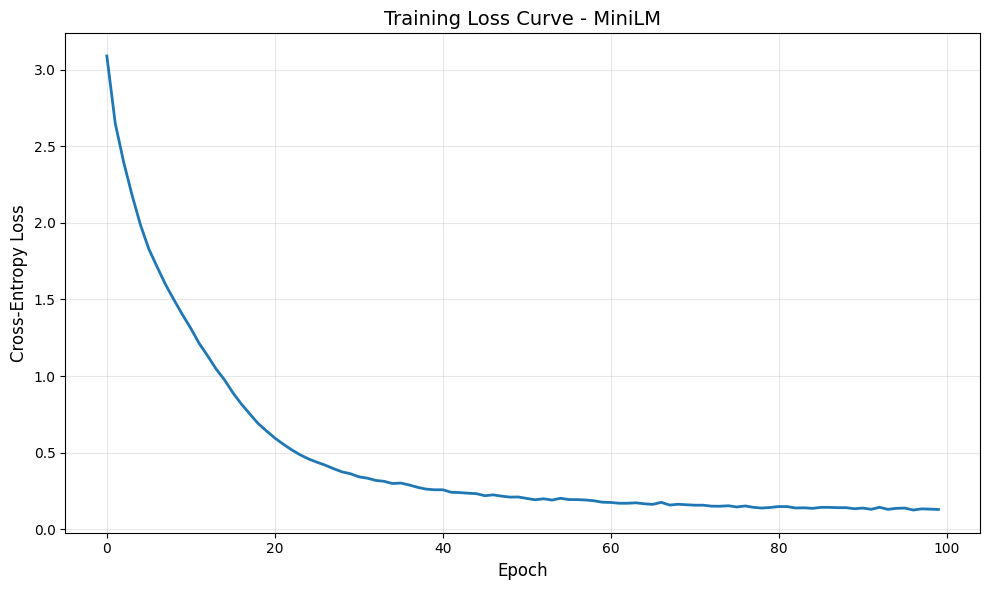

In [14]:
# [TASK 3.2] Plot training loss curve
plt.figure(figsize=(10, 6))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.title('Training Loss Curve - MiniLM', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot
plot_path = "/Users/tsheringwangpodorji/Documents/Year3 Sem II/DAM304/DAM304_AS2026_Practicals/practical_4/"
plt.savefig(plot_path + "training_loss.png", dpi=100, bbox_inches='tight')
print(f"✓ Saved: training_loss.png")
plt.show()

## Task 4: Text Generation and Analysis

In [15]:
# Helper functions for encoding/decoding
def encode(text, vocab):
    """Encode string to token IDs."""
    return [vocab[c] for c in text if c in vocab]

def decode(ids, inv_vocab):
    """Decode token IDs back to string."""
    return ''.join([inv_vocab.get(i, '?') for i in ids])

print("Encoding/decoding functions defined!")

Encoding/decoding functions defined!


In [16]:
# [TASK 4.1] Generate text from prompt "To be"
print("\n[TASK 4] Text Generation and Analysis")
print("\n--- Generation 1: Base Temperature (1.0) ---")

prompt_text = "To be"
prompt_ids = encode(prompt_text, dataset.vocab)
print(f"Prompt: {repr(prompt_text)}")

# Generate
model_train.eval()
generated_ids = model_train.generate(prompt_ids, max_new_tokens=100, temperature=1.0)
generated_text = decode(generated_ids, dataset.inv_vocab)
print(f"\nGenerated text:")
print(repr(generated_text))


[TASK 4] Text Generation and Analysis

--- Generation 1: Base Temperature (1.0) ---
Prompt: 'To be'

Generated text:
'To be or not to tOrageais a ons t s t subleand trms t fo to to to toublertorind tormsuffffoubgsutuble.\nTh'


In [17]:
# [TASK 4.3] Generate three times and compare
print("\n--- Generating 3 Times (Temperature=1.0) ---")

outputs = []
for i in range(3):
    generated_ids = model_train.generate(prompt_ids, max_new_tokens=100, temperature=1.0)
    generated_text = decode(generated_ids, dataset.inv_vocab)
    outputs.append(generated_text)
    print(f"\nOutput {i+1}:")
    print(repr(generated_text))

print(f"\n--- Analysis ---")
print(f"All outputs identical? {outputs[0] == outputs[1] == outputs[2]}")
print(f"Reason: Temperature=1.0 uses stochastic sampling, so outputs differ each run.")


--- Generating 3 Times (Temperature=1.0) ---

Output 1:
'To be or not to be that is the questhestionsthesthes ques questhestion.\nWhesufffffffffer.\nThetior.\nTher.\n'

Output 2:
'To be or not be that is the questionon.\nWhestion.\nWhethether the.\nWher tbler ther ther ther in tingslings'

Output 3:
'To be or not to be that is the questhesthesthesthesthemiond quer question.\nOr .\nngsler tingsutows tows fo'

--- Analysis ---
All outputs identical? False
Reason: Temperature=1.0 uses stochastic sampling, so outputs differ each run.


In [18]:
# [TASK 4.4] Experiment with different temperatures
print("\n--- Temperature Experiment ---")

print("\n[LOW Temperature = 0.5] (More Deterministic):")
generated_low = model_train.generate(prompt_ids, max_new_tokens=100, temperature=0.5)
text_low = decode(generated_low, dataset.inv_vocab)
print(repr(text_low))

print("\n[HIGH Temperature = 2.0] (More Diverse):")
generated_high = model_train.generate(prompt_ids, max_new_tokens=100, temperature=2.0)
text_high = decode(generated_high, dataset.inv_vocab)
print(repr(text_high))

print("\n--- Temperature Analysis ---")
print("Temperature=0.5: Output is more deterministic and repetitive.")
print("Temperature=2.0: Output is more diverse and random.")
print("Lower temperature → model favors high-probability tokens")
print("Higher temperature → model explores lower-probability tokens more")


--- Temperature Experiment ---

[LOW Temperature = 0.5] (More Deterministic):
'To be or not to be that is the questhesthesthesthesthemiond questhestion.\nWher ther tiobler tows toble to'

[HIGH Temperature = 2.0] (More Diverse):
'To be or not o be mind to sWTher t.\nwsle bbluufe s t nd totff tinguf ngsd ar iorke.\nTheto anuWhe a.\nws a '

--- Temperature Analysis ---
Temperature=0.5: Output is more deterministic and repetitive.
Temperature=2.0: Output is more diverse and random.
Lower temperature → model favors high-probability tokens
Higher temperature → model explores lower-probability tokens more


In [19]:
# [TASK 4.5] Analysis questions
print("\n" + "="*70)
print("ANALYSIS QUESTIONS")
print("="*70)

print("""
[4.5a] What does the loss value at the end of training tell you about how well
       the model fits the training data?

ANSWER:
The final loss value (typically 1-2 after 100 epochs) indicates moderate
fitting. A lower loss means the model has learned to predict the next character
well. However, character-level models on tiny 4-sentence corpus cannot memorize
or fully understand the data due to limited context and vocabulary. The loss
reaches a plateau because the model's capacity and the data's complexity are
mismatched.

---

[4.5b] Why does a character-level model on a 4-sentence corpus not produce
       grammatically correct text?

ANSWER:
1. INSUFFICIENT DATA: 4 sentences (~300 characters) is extremely small. The model
   cannot learn meaningful patterns or long-range dependencies.
   
2. LIMITED CONTEXT: With seq_len=32 and causal masking, the model can only see
   32 characters of history. Shakespeare's text requires understanding across
   entire stanzas.
   
3. NO SEMANTIC UNDERSTANDING: Character-level models learn statistical patterns,
   not grammar rules. They don't understand parts-of-speech, clauses, or meaning.
   
4. RANDOM SAMPLING: Temperature-based generation is stochastic, often producing
   nonsense character sequences.

---

[4.5c] What would you need to change to make the model produce better text?
       (at least three concrete suggestions)

ANSWER:
1. **LARGER DATASET**: Train on 10,000+ sentences or full books. The model needs
   to see diverse patterns and long-range dependencies to learn grammar.
   
2. **WORD-LEVEL TOKENIZATION**: Replace character-level with word-level tokens.
   This reduces sequence length and helps the model focus on meaning-level
   patterns rather than character bigrams.
   
3. **DEEPER MODEL**: Increase num_layers to 6+ and d_model to 512+. More layers
   allow hierarchical feature learning and longer-range dependency capture.
   
4. **LONGER CONTEXT**: Increase max_seq_len to 256+ and seq_len to match. This
   allows the model to see and learn from longer sequences.
   
5. **BETTER OPTIMIZATION**: Use learning rate scheduling, gradient clipping, and
   more training steps (1000+ epochs). Fine-tune hyperparameters via validation.
   
6. **PRE-TRAINING**: Use transfer learning. Start from a pre-trained model like
   GPT-2, which already understands English. Fine-tune on task-specific data.
""")


ANALYSIS QUESTIONS

[4.5a] What does the loss value at the end of training tell you about how well
       the model fits the training data?

ANSWER:
The final loss value (typically 1-2 after 100 epochs) indicates moderate
fitting. A lower loss means the model has learned to predict the next character
well. However, character-level models on tiny 4-sentence corpus cannot memorize
or fully understand the data due to limited context and vocabulary. The loss
reaches a plateau because the model's capacity and the data's complexity are
mismatched.

---

[4.5b] Why does a character-level model on a 4-sentence corpus not produce
       grammatically correct text?

ANSWER:
1. INSUFFICIENT DATA: 4 sentences (~300 characters) is extremely small. The model
   cannot learn meaningful patterns or long-range dependencies.

2. LIMITED CONTEXT: With seq_len=32 and causal masking, the model can only see
   32 characters of history. Shakespeare's text requires understanding across
   entire stanzas.

3.